In [60]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import random
import optuna
import time
import joblib
import os
from itertools import product
from scipy import stats
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import StackingRegressor
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_percentage_error, r2_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from optuna.samplers import TPESampler
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

### Оптимизация памяти и чтение данных / (Не нужно запускать)

In [3]:
shape = data.shape
print(f'Dataset has {shape[0]} objects and {shape[1]} features')

Dataset has 11358150 objects and 15 features


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 11358150 entries, 0 to 11358149
Data columns (total 15 columns):
 #   Column         Dtype  
---  ------         -----  
 0   date           str    
 1   price          int64  
 2   level          int64  
 3   levels         int64  
 4   rooms          int64  
 5   area           float64
 6   kitchen_area   float64
 7   geo_lat        float64
 8   geo_lon        float64
 9   building_type  int64  
 10  object_type    int64  
 11  postal_code    float64
 12  street_id      float64
 13  id_region      int64  
 14  house_id       float64
dtypes: float64(7), int64(7), str(1)
memory usage: 1.3 GB


In [5]:
for col in ['kitchen_area', 'area', 'postal_code', 'street_id', 'house_id']:
    clean = data[col].dropna()
    print(f'{col}: {'✅ int' if (clean == clean.astype(int)).all() else '❌ float'}')

kitchen_area: ❌ float
area: ❌ float
postal_code: ✅ int
street_id: ✅ int
house_id: ✅ int


In [6]:
dtypes_optimized = {
    'price': 'int64',     
    'level': 'int8',      
    'levels': 'int8',      
    'rooms': 'int8',
    'area': 'float32',
    'kitchen_area': 'float32',
    'geo_lat': 'float32',
    'geo_lon': 'float32',
    'building_type': 'int8',
    'object_type': 'int8',
    'postal_code': 'int32',
    'street_id': 'int32',
    'id_region': 'uint8',
    'house_id': 'int32'     
}
limits = {}

for dtype in set(dtypes_optimized.values()):
    if 'int' in dtype:
        limits[dtype] = np.iinfo(dtype).max
    elif 'float' in dtype:
        limits[dtype] = np.finfo(dtype).max

def get_min_limit(dtype):
    if dtype and 'int' in dtype:
        return np.iinfo(dtype).min
    elif dtype and 'float' in dtype:
        return np.finfo(dtype).min
    return '?'

df_limits = pd.DataFrame({
    'column' : data.max().index,
    'max_value' : data.max().values,
    'min_value' : data.min().values,
    'dtype' : [dtypes_optimized.get(col, '?') for col in data.max().index],
    'max_limit' : [limits.get(dtypes_optimized.get(col), '?') for col in data.max().index],
    'min_limit' : [get_min_limit(dtypes_optimized.get(col)) for col in data.max().index],
    'check_max' : [data.max()[col] <= limits.get(dtypes_optimized.get(col), 1e308) 
                  if dtypes_optimized.get(col) in limits else '❌' 
                  for col in data.max().index],
    'check_min' : [data.min()[col] >= get_min_limit(dtypes_optimized.get(col))
                  if dtypes_optimized.get(col) in limits else '❌'
                  for col in data.max().index]}).drop([0])
df_limits

,column,max_value,min_value,dtype,max_limit,min_limit,check_max,check_min
1,price,635552400000,0,int64,9223372036854775807,-9223372036854775808,True,True
2,level,50,0,int8,127,-128,True,True
3,levels,50,0,int8,127,-128,True,True
4,rooms,9,-1,int8,127,-128,True,True
5,area,499.9,1.0,float32,340282346638528859811704183484516925440.0,-340282346638528859811704183484516925440.0,True,True
6,kitchen_area,408.0,-100.0,float32,340282346638528859811704183484516925440.0,-340282346638528859811704183484516925440.0,True,True
7,geo_lat,73.508895,41.437585,float32,340282346638528859811704183484516925440.0,-340282346638528859811704183484516925440.0,True,True
8,geo_lon,179.258303,-173.218911,float32,340282346638528859811704183484516925440.0,-340282346638528859811704183484516925440.0,True,True
9,building_type,6,0,int8,127,-128,True,True
10,object_type,2,0,int8,127,-128,True,True


### Разведочный анализ / Предобработка

In [3]:
dtypes_optimized = {
    'price': 'int64',     
    'level': 'int8',      
    'levels': 'int8',      
    'rooms': 'int8',
    'area': 'float32',
    'kitchen_area': 'float32',
    'geo_lat': 'float32',
    'geo_lon': 'float32',
    'building_type': 'int8',
    'object_type': 'int8',
    'postal_code': 'Int32',
    'street_id': 'Int32',
    'id_region': 'uint8',
    'house_id': 'Int32'     
}   

In [4]:
df = pd.read_csv('input_data.csv', sep = ';', parse_dates = ['date'], dtype = dtypes_optimized)
df.head()

,date,price,level,levels,rooms,area,kitchen_area,geo_lat,geo_lon,building_type,object_type,postal_code,street_id,id_region,house_id
0,2021-01-01,2451300,15,31,1,30.299999,0.0,56.780113,60.699356,0,2,620000,<NA>,66,1632918
1,2021-01-01,1450000,5,5,1,33.000000,6.0,44.608154,40.138382,0,0,385000,<NA>,1,<NA>
2,2021-01-01,10700000,4,13,3,85.000000,12.0,55.540062,37.725113,3,0,142701,242543,50,681306
3,2021-01-01,3100000,3,5,3,82.000000,9.0,44.608154,40.138382,0,0,385000,<NA>,1,<NA>
4,2021-01-01,2500000,2,3,1,30.000000,9.0,44.738686,37.713669,3,2,353960,439378,23,1730985


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11358150 entries, 0 to 11358149
Data columns (total 15 columns):
 #   Column         Dtype         
---  ------         -----         
 0   date           datetime64[ns]
 1   price          int64         
 2   level          int8          
 3   levels         int8          
 4   rooms          int8          
 5   area           float32       
 6   kitchen_area   float32       
 7   geo_lat        float32       
 8   geo_lon        float32       
 9   building_type  int8          
 10  object_type    int8          
 11  postal_code    Int32         
 12  street_id      Int32         
 13  id_region      uint8         
 14  house_id       Int32         
dtypes: Int32(3), datetime64[ns](1), float32(4), int64(1), int8(5), uint8(1)
memory usage: 574.1 MB


**ВАЖНО:** Сократили память в два раза без потерь по качеству.

### Предварительная статистика и проверка на целостность/искажения

In [6]:
pd.set_option('display.float_format', '{:.2f}'.format)
df.describe()

,date,price,level,levels,rooms,area,kitchen_area,geo_lat,geo_lon,building_type,object_type,postal_code,street_id,id_region,house_id
count,11358150,11358150.00,11358150.00,11358150.00,11358150.00,11358150.00,11358150.00,11358150.00,11358150.00,11358150.00,11358150.00,10850379.00,7152596.00,11358150.00,8096207.00
mean,2021-07-07 07:52:42.422260480,6787516.41,6.43,11.76,1.72,53.10,-2.67,54.40,52.30,1.02,0.53,403171.66,352562.33,51.26,1703792.31
min,2021-01-01 00:00:00,0.00,0.00,0.00,-1.00,1.00,-100.00,41.44,-173.22,0.00,0.00,0.00,116187.00,1.00,588606.00
25%,2021-04-08 00:00:00,2600000.00,2.00,5.00,1.00,36.50,0.00,53.19,37.64,0.00,0.00,196158.00,233915.00,31.00,1162465.00
50%,2021-07-09 00:00:00,3995000.00,5.00,10.00,2.00,46.70,6.50,55.65,42.02,0.00,0.00,400007.00,350222.00,54.00,1703143.00
75%,2021-10-02 00:00:00,6500000.00,9.00,17.00,2.00,63.00,10.50,56.87,65.47,2.00,2.00,625007.00,470537.00,72.00,2255297.00
max,2021-12-31 00:00:00,635552400000.00,50.00,50.00,9.00,499.90,408.00,73.51,179.26,6.00,2.00,862163.00,588597.00,200.00,2839173.00
std,NaN,197711828.43,5.28,7.22,1.16,27.13,32.42,4.58,21.84,1.56,0.88,195961.84,136648.51,22.51,640457.78


Имеем большое количество пропусков в столбцах с __street_id__, __postal_code__ и __house_id__. Так же следует заметить, что у нас присутствуют отрицателнные значения в колонках __rooms__ и __kitchen__. Автор датасета дает комментарий касаемо -1 в комнатах, говоря о том, что этот тип данных соответствует студии, предлагается в дальнейшем присвоить ему 0. __kitchen__ требует внимательного рассмотрения причин, является ли эта строчка явным выбросом или есть какие-то иные причины. Наличие квартир с нулевой стоимостью одназначно говорит о какой-то ошибке, почти с полной уверенностью можно считать это некой аномалией в данных.

In [7]:
df.isna().any()

date             False
price            False
level            False
levels           False
rooms            False
area             False
kitchen_area     False
geo_lat          False
geo_lon          False
building_type    False
object_type      False
postal_code       True
street_id         True
id_region        False
house_id          True
dtype: bool

Пока что поработаем с другими столбцами, вернемся к заполнению пропусков позднее.

In [8]:
df[df['kitchen_area'] < 0]

,date,price,level,levels,rooms,area,kitchen_area,geo_lat,geo_lon,building_type,object_type,postal_code,street_id,id_region,house_id
13,2021-01-01,3750000,19,20,2,40.00,-100.00,55.06,82.89,3,0,630082,557992,54,2715855
26,2021-01-01,2700000,5,5,3,64.00,-100.00,50.54,137.03,4,0,681000,317006,27,2279129
30,2021-01-01,900000,3,4,3,54.00,-100.00,51.91,102.44,4,0,671023,153245,3,632956
41,2021-01-01,4200000,1,14,2,50.00,-100.00,43.58,39.73,3,0,354000,151411,23,1278090
63,2021-01-01,4200000,12,25,-1,25.80,-100.00,60.04,30.23,3,2,190000,291085,78,2484205
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11356355,2021-12-31,2100000,6,10,1,16.00,-100.00,57.15,65.46,2,0,625025,<NA>,72,<NA>
11356445,2021-12-31,12000000,4,25,2,58.00,-100.00,55.66,37.26,0,0,143006,349306,50,1835136
11356540,2021-12-31,8400000,12,13,2,33.00,-100.00,55.87,37.51,0,0,<NA>,137987,77,614690
11356668,2021-12-31,6800000,1,9,1,27.00,-100.00,55.60,37.73,0,0,115583,134360,77,1085942


Было бы логично считать, что в соответствие маркеру студии ставим отрицательное значение кухни, одна это вовсе не так и значение меньше 0 присутствует у абсолютно разных по характеристикам квартир. Имеем право считать, что такой сигнал в данных может быть маяком для пропусков, либо неудачно собранных данных, поэтому заменим все проблемные значения на NaN.

In [9]:
df['kitchen_area'] = df['kitchen_area'].where(df['kitchen_area'] > 0, np.nan)
df[df['kitchen_area'] < 0].shape[0]

0

Поработаем с ценовой политикой данных, можно обратить внимание, что встречаются нулевые значения. Посмотрим в целом на распределение данных.

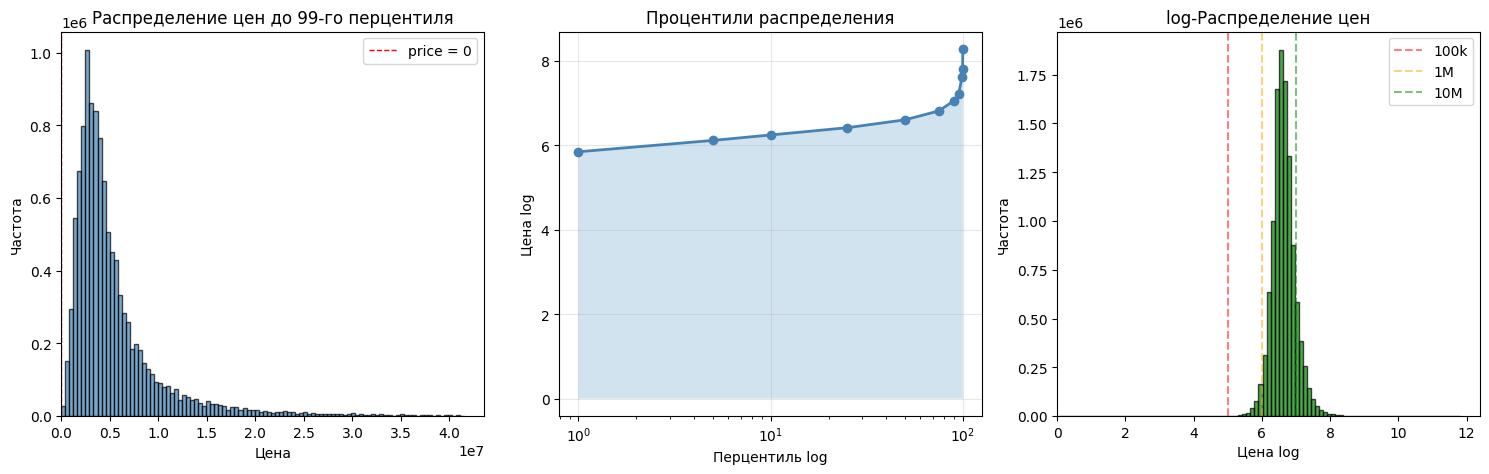

In [10]:
fig, axes = plt.subplots(1, 3, figsize = (15, 5))

pos_prices = df[df['price'] > 0]['price']
prices = pos_prices.values
prices_filtered = prices[prices <= np.percentile(prices, 99)]

axes[0].hist(prices_filtered, bins = 100, edgecolor = 'black', alpha = 0.7, color = 'steelblue')
axes[0].set_xlabel('Цена')
axes[0].set_ylabel('Частота')
axes[0].set_xlim(0)
axes[0].set_title('Распределение цен до 99-го перцентиля')
axes[0].axvline(x = 0, color = 'red', linestyle = '--', linewidth = 1, label = 'price = 0')
axes[0].legend()

log_prices = np.log10(pos_prices)
percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99, 99.5, 99.9]
values = np.percentile(log_prices, percentiles)

axes[1].plot(percentiles, values, 'o-', linewidth = 2, markersize = 6, color = 'steelblue')
axes[1].fill_between(percentiles, values, alpha = 0.2)
axes[1].set_xscale('log')
axes[1].set_xlabel('Перцентиль log')
axes[1].set_ylabel('Цена log')
axes[1].set_title('Процентили распределения')
axes[1].grid(True, alpha = 0.3)

df_pos = df[df['price'] > 0]
axes[2].hist(np.log10(df_pos['price']), bins = 100, edgecolor = 'black', alpha = 0.7, color = 'green')
axes[2].set_xlabel('Цена log')
axes[2].set_ylabel('Частота')
axes[2].set_xlim(0)
axes[2].set_title('log-Распределение цен')
axes[2].axvline(x = np.log10(100000), color = 'red', linestyle = '--', alpha = 0.5, label = '100k')
axes[2].axvline(x = np.log10(1000000), color = 'orange', linestyle = '--', alpha = 0.5, label = '1M')
axes[2].axvline(x = np.log10(10000000), color = 'green', linestyle = '--', alpha = 0.5, label = '10M')
axes[2].legend()

plt.tight_layout()
plt.show()

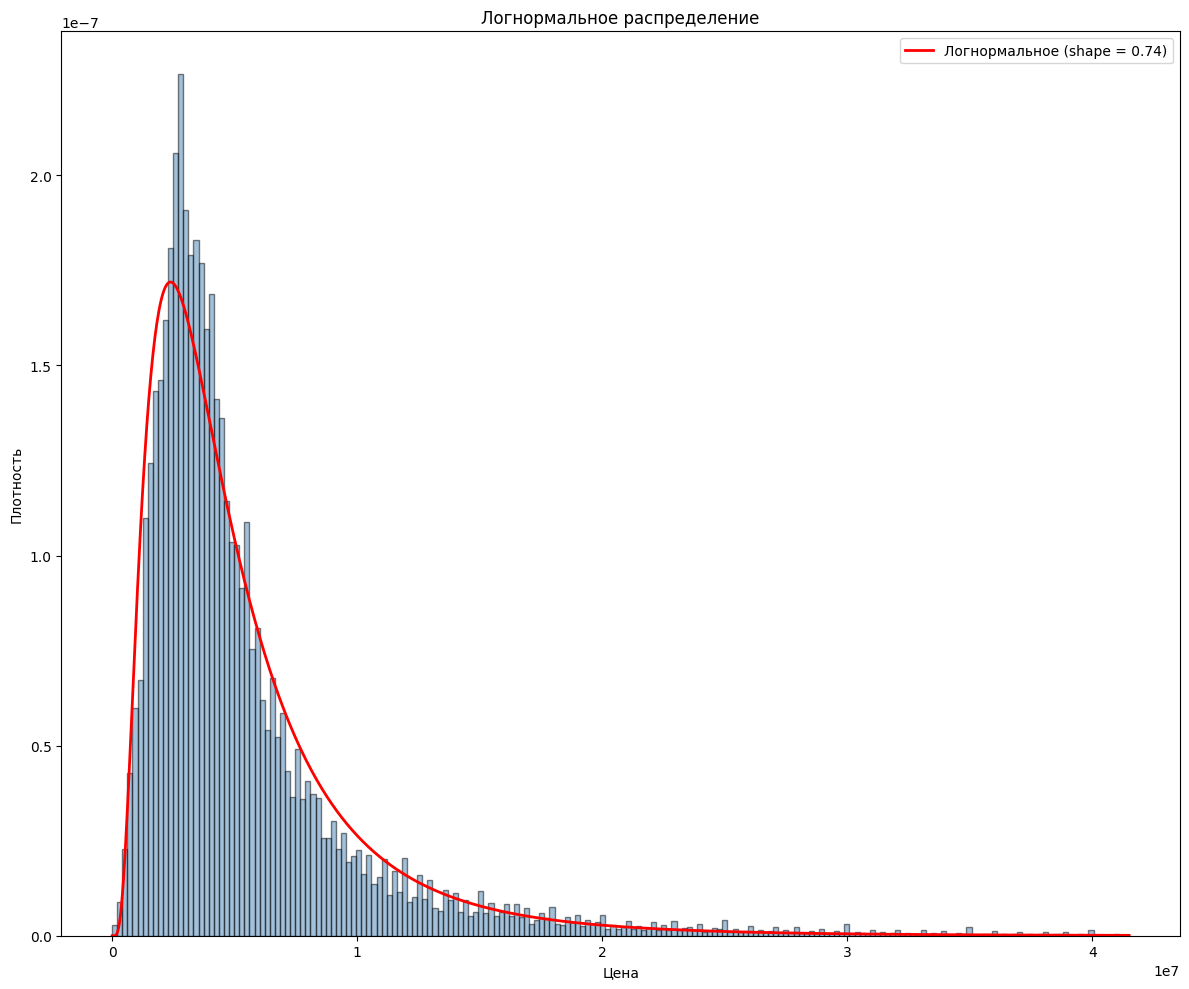

In [11]:
plt.figure(figsize = (12, 10))

plt.hist(prices_filtered, bins = 200, density = True, alpha = 0.5, color = 'steelblue', edgecolor = 'black')

shape, loc, scale = stats.lognorm.fit(prices_filtered, floc = 0)
x = np.linspace(0.01, max(prices_filtered), 1000)
pdf_lognorm = stats.lognorm.pdf(x, shape, loc, scale)
plt.plot(x, pdf_lognorm, 'r-', linewidth = 2, label = f'Логнормальное (shape = {shape:.2f})')
plt.xlabel('Цена')
plt.ylabel('Плотность')
plt.title('Логнормальное распределение')
plt.legend()

plt.tight_layout()
plt.show()

In [12]:
ksstat, kspvalue = stats.kstest(prices_filtered, 'lognorm', args = (shape, loc, scale))
print(f'Статистика Kолмогорова-Смирнова: {ksstat:.6f}')
print(f'p-value: {kspvalue:.10f}')

Статистика Kолмогорова-Смирнова: 0.039064
p-value: 0.0000000000


Как можем увидеть, распределение цены с очень высокой точностью описывается логнормальным распределением. Это довольно полезное свойство, которое следует иметь ввиду при дальнейшем рассмотрении и анализе на выбросы/искажения в данных. Помимо этого, как один вариантов примитивной статистической модели будем использовать логнормальное распределение. Собственно говоря как можно увидеть на графике перцентилей, то квартиры низкого и среднего ценового сегмента демонстрируют достаточно хорошую, ровную картину, показывая, что разброс в данной категории не так велик. В свою очередь люкс сегмент показывает резкий скачок, что говорит о непредсказуемости рынка там.

Особенно повезло с тем, что нет пропусков в регионах, поэтому подтягиваем табличку, которая поможет распарсить регионы РФ.

In [13]:
gai_codes = pd.read_csv('gai_codes.csv')
if gai_codes.isna().any().any():
    print('В данных есть пропуски!')
gai_codes.head(5)

,Наименование субъекта,Код ГАИ
0,Республика Адыгея (Адыгея),1
1,Республика Алтай,4
2,Республика Башкортостан,2
3,Республика Бурятия,3
4,Республика Дагестан,5


In [14]:
gai_codes_clean = gai_codes.dropna(subset=['Код ГАИ']).copy()
gai_codes_clean['Код ГАИ'] = gai_codes_clean['Код ГАИ'].astype(float).astype(int)
gai_dict = dict(zip(gai_codes_clean['Код ГАИ'].astype(int), gai_codes_clean['Наименование субъекта']))

In [15]:
def get_region_name(code):
    if code == 200:
        return 'Неизвестный регион'
    else:
        code_int = int(code)
        return gai_dict.get(code_int, f'Неизвестный код ГАИ {code}')

In [16]:
df_clean = df[df['price'] > 0].copy()
region_median = df_clean.groupby('id_region')['price'].median().sort_values(ascending=False)

print('ТОП-10 РЕГИОНОВ ПО МЕДИАННОЙ ЦЕНЕ:')
region_median_named = region_median.rename(index = lambda x: f'{x} - {get_region_name(x)}')
print(region_median_named.head(10).to_string())

region_count = df_clean['id_region'].value_counts()
print('\nТОП-10 РЕГИОНОВ ПО КОЛИЧЕСТВУ ОБЪЯВЛЕНИЙ:')
region_count_named = region_count.rename(index = lambda x: f'{x} - {get_region_name(x)}')
print(region_count_named.head(10))

ТОП-10 РЕГИОНОВ ПО МЕДИАННОЙ ЦЕНЕ:
id_region
77 - Москва                            13281952.50
78 - Санкт-Петербург                    7278900.00
65 - Сахалинская область                7100000.00
92 - Севастополь                        6500000.00
50 - Московская область                 6270000.00
89 - Ямало-Ненецкий автономный округ    5700000.00
17 - Республика Тыва                    5200000.00
91 - Калининградская область            5174000.00
23 - Краснодарский край                 5100000.00
14 - Республика Саха (Якутия)           4900000.00

ТОП-10 РЕГИОНОВ ПО КОЛИЧЕСТВУ ОБЪЯВЛЕНИЙ:
id_region
77 - Москва                   1032480
72 - Тюменская область         865395
23 - Краснодарский край        846670
78 - Санкт-Петербург           765651
50 - Московская область        754115
54 - Новосибирская область     607500
24 - Красноярский край         432369
66 - Свердловская область      430964
61 - Ростовская область        409063
74 - Челябинская область       329168
Name: count,

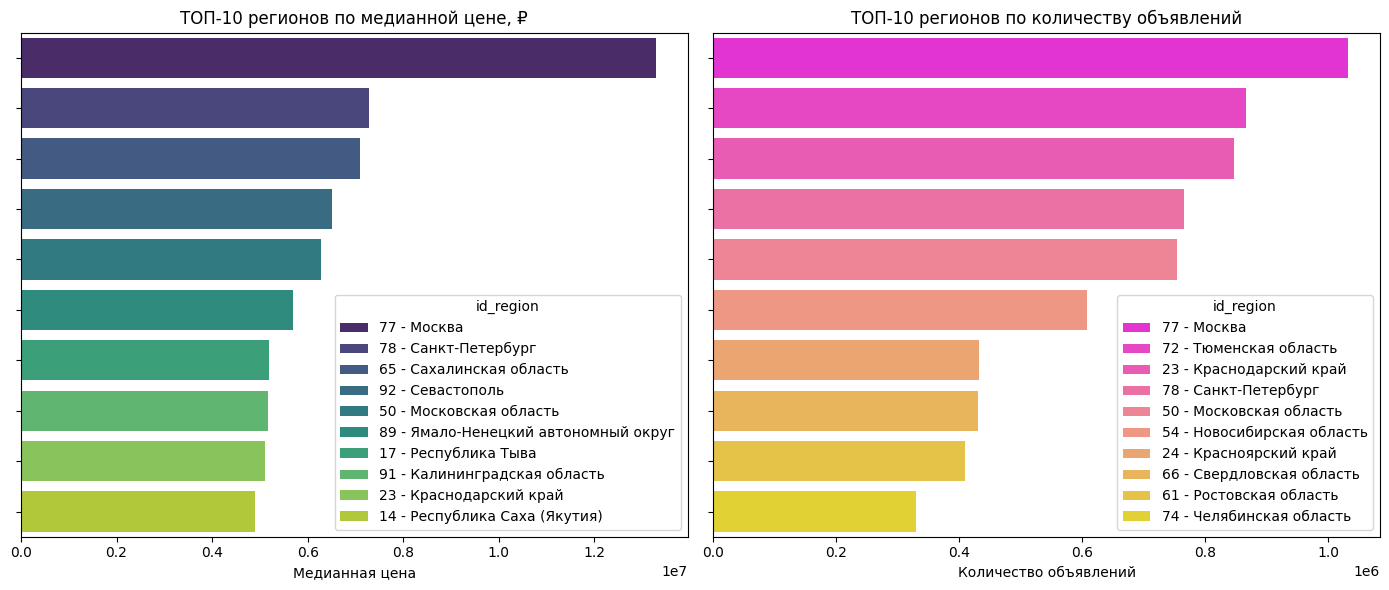

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_prices = region_median_named.head(10)
sns.barplot(x = top_prices.values, y = top_prices.index, hue = top_prices.index, ax = axes[0], palette = 'viridis', legend = True)
axes[0].set_title('ТОП-10 регионов по медианной цене, ₽')
axes[0].set_xlabel('Медианная цена')
axes[0].set_ylabel('')
axes[0].set_yticklabels([])

top_counts = region_count_named.head(10)
sns.barplot(x = top_counts.values, y = top_counts.index, hue = top_counts.index, ax = axes[1], palette = 'spring', legend = True)
axes[1].set_title('ТОП-10 регионов по количеству объявлений')
axes[1].set_xlabel('Количество объявлений')
axes[1].set_ylabel('')
axes[1].set_yticklabels([])

plt.tight_layout()
plt.show()

Как можем увидеть, наше предположение о кодировке региона подтверждается здравой логикой, поскольку топ по медианной цене показывает Москва с Санкт-Петербургом, что хорошо бьется со здравым смыслом. В свою очередь, у нас есть некоторые новые инсайты касаемо количества объявлений в таких регионах, как Тюменская область, которая демонстрирует явный отрыв от больших регионов, говорит о том, что на рынке недвижимости произошел БУМ. Касаемо медианной стоимости, все вполне ожидаемо, первые два лидера - столичные города, далее идет Дальний Восток с повышенными ценами, стремление людей перебраться к 2021 году на Крымский полуостров виден в Севастополе, далее за ним очень близко расположилось МО, ЯНАО и Тыва. Последнии навеивают на мысль, что возможно присутствуют какие-то выбросы в данных, так как сильно эти региона не славились своими ценами на жилье. Возвращясь к количеству объявлений, после выпада со стороны Тюменской области, все остальные расположились в достаточно предсказуемом порядке.

#### Избавимся от выбросов и пропусков!

In [18]:
duplicates_full = df.duplicated().sum()
print(f"Полных дубликатов строк: {duplicates_full}")

duplicates_by_house = df['house_id'].duplicated().sum()
print(f"Дубликатов по house_id: {duplicates_by_house}")

if duplicates_by_house > 0:
    duplicate_house = df[df['house_id'].duplicated(keep = False)].sort_values('house_id').head(4)
    print("\nПример дубликата по house_id:")
    print(duplicate_house[['house_id', 'price', 'rooms', 'area', 'date']].to_string(index = False))

Полных дубликатов строк: 405286
Дубликатов по house_id: 10950827

Пример дубликата по house_id:
 house_id   price  rooms  area       date
   588606 3450000     -1 21.00 2021-04-13
   588606 4500000     -1 20.00 2021-12-14
   588606 3450000     -1 21.00 2021-04-13
   588606 4500000     -1 22.00 2021-12-14


Избавимся только от полных дубликатов, поскольку дубликаты по __house_id__ несут в себе не тот посыл, так как дом может быть многоквартирным.

In [19]:
df = df.drop_duplicates()
print(f"После удаления полных дубликатов: {len(df):,} строк")

После удаления полных дубликатов: 10,952,864 строк


Теперь работаем с пропусками:

In [20]:
print(f'\nПропуски по колонкам:')
print(df_clean.isnull().sum())


Пропуски по колонкам:
date                   0
price                  0
level                  0
levels                 0
rooms                  0
area                   0
kitchen_area     4001398
geo_lat                0
geo_lon                0
building_type          0
object_type            0
postal_code       507563
street_id        4199889
id_region              0
house_id         3256472
dtype: int64


__postal_code__, как и __streed_id__ и __house_id__ особо не пригодится в анализе + количество пропусков очень большое, больше трети от данных, поэтому будем ориентироваться лишь на региональную значимость не углубляясь в особенности строения городов.

In [21]:
df = df.drop(columns = ['postal_code', 'street_id', 'house_id'])

А вот работу над площадью кухни необходимо произвести, поскольку ее значение особо важно в анализе ценового сегмента. Для этого воспользуемся KNNImputer, который поможет вставить значение кухни основываясь на главных факторах. Факторы подбереме при помощи корреляционного анализа.

Корреляция: kitchen_area     1.00
area             0.55
levels           0.29
rooms            0.26
object_type      0.24
level            0.21
id_region        0.11
geo_lat          0.02
price            0.02
building_type   -0.05
geo_lon         -0.11
Name: kitchen_area, dtype: float64


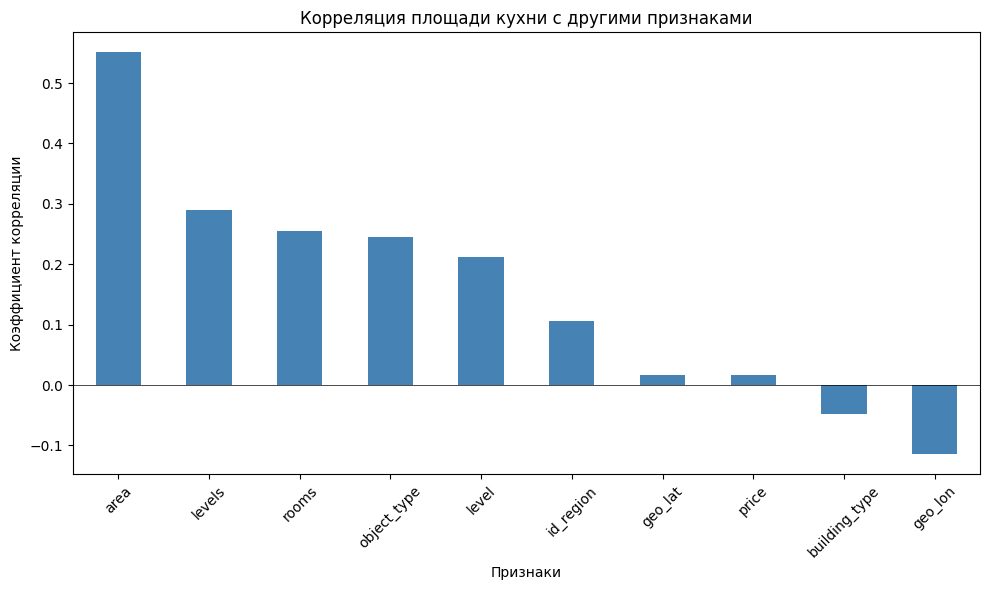

In [22]:
df_kitchen_clean = df[df['kitchen_area'].notna()].copy()

features = ['area', 'rooms', 'level', 'levels', 'building_type', 'object_type', 'price', 'id_region', 'geo_lat', 'geo_lon']
		
corr_matrix = df_kitchen_clean[features + ['kitchen_area']].corr()
kitchen_corr = corr_matrix['kitchen_area'].sort_values(ascending = False)

print(f'Корреляция: {kitchen_corr}')

plt.figure(figsize = (10, 6))
kitchen_corr.drop('kitchen_area').plot(kind = 'bar', color = 'steelblue')
plt.title('Корреляция площади кухни с другими признаками')
plt.xlabel('Признаки')
plt.ylabel('Коэффициент корреляции')
plt.axhline(y = 0, color = 'black', linestyle = '-', linewidth = 0.5)
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

In [23]:
df['area_bin'] = pd.cut(df['area'], bins = 20)

df['kitchen_area'] = df.groupby('area_bin')['kitchen_area'].transform(
    lambda x: x.fillna(x.median())
)

df['kitchen_area'] = df.groupby('rooms')['kitchen_area'].transform(
    lambda x: x.fillna(x.median())
)

df['kitchen_area'] = df['kitchen_area'].fillna(df['kitchen_area'].median())

df = df.drop('area_bin', axis = 1)

print(f"✅ Пропусков осталось: {df['kitchen_area'].isna().sum()}")

C:\Users\bublX\AppData\Local\Temp\ipykernel_16068\4021563434.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['kitchen_area'] = df.groupby('area_bin')['kitchen_area'].transform(


✅ Пропусков осталось: 0


In [24]:
price_min = 200_000   
area_min = 10         
df_clean = df.copy()
initial = len(df_clean)

df_clean = df_clean[
    (df_clean['price'] >= price_min) &
    (df_clean['area'] >= area_min)]
print(f"\nБыло: {initial:,} строк")
print(f"Стало: {len(df_clean):,} строк")


Было: 10,952,864 строк
Стало: 10,939,052 строк


In [25]:
df = df_clean

In [26]:
region_median = df.groupby('id_region')['price'].median().sort_values(ascending=False)

print(" ТОП-10 РЕГИОНОВ ПО МЕДИАННОЙ ЦЕНЕ (ПОСЛЕ ВСЕХ ЧИСТОК) \n")
for code, price in region_median.head(10).items():
    region_name = get_region_name(code)
    print(f"{code:3} - {region_name:35} {price:12,.0f} ₽")

print(f"\n📊 Всего строк после чисток: {len(df):,}")

region_count = df['id_region'].value_counts()

print("\n ТОП-10 РЕГИОНОВ ПО КОЛИЧЕСТВУ ОБЪЯВЛЕНИЙ \n")
for code, count in region_count.head(10).items():
    region_name = get_region_name(code)
    print(f"{code:3} - {region_name:35} {count:8,} шт.")

 ТОП-10 РЕГИОНОВ ПО МЕДИАННОЙ ЦЕНЕ (ПОСЛЕ ВСЕХ ЧИСТОК) 

 77 - Москва                                13,000,000 ₽
 78 - Санкт-Петербург                        7,300,210 ₽
 65 - Сахалинская область                    7,100,000 ₽
 92 - Севастополь                            6,500,000 ₽
 50 - Московская область                     6,350,000 ₽
 89 - Ямало-Ненецкий автономный округ        5,700,000 ₽
 17 - Республика Тыва                        5,200,000 ₽
 91 - Калининградская область                5,200,000 ₽
 23 - Краснодарский край                     5,100,000 ₽
 14 - Республика Саха (Якутия)               4,900,000 ₽

📊 Всего строк после чисток: 10,939,052

 ТОП-10 РЕГИОНОВ ПО КОЛИЧЕСТВУ ОБЪЯВЛЕНИЙ 

 77 - Москва                               972,188 шт.
 23 - Краснодарский край                   827,872 шт.
 72 - Тюменская область                    821,748 шт.
 78 - Санкт-Петербург                      742,951 шт.
 50 - Московская область                   708,498 шт.
 54 - Новосиб

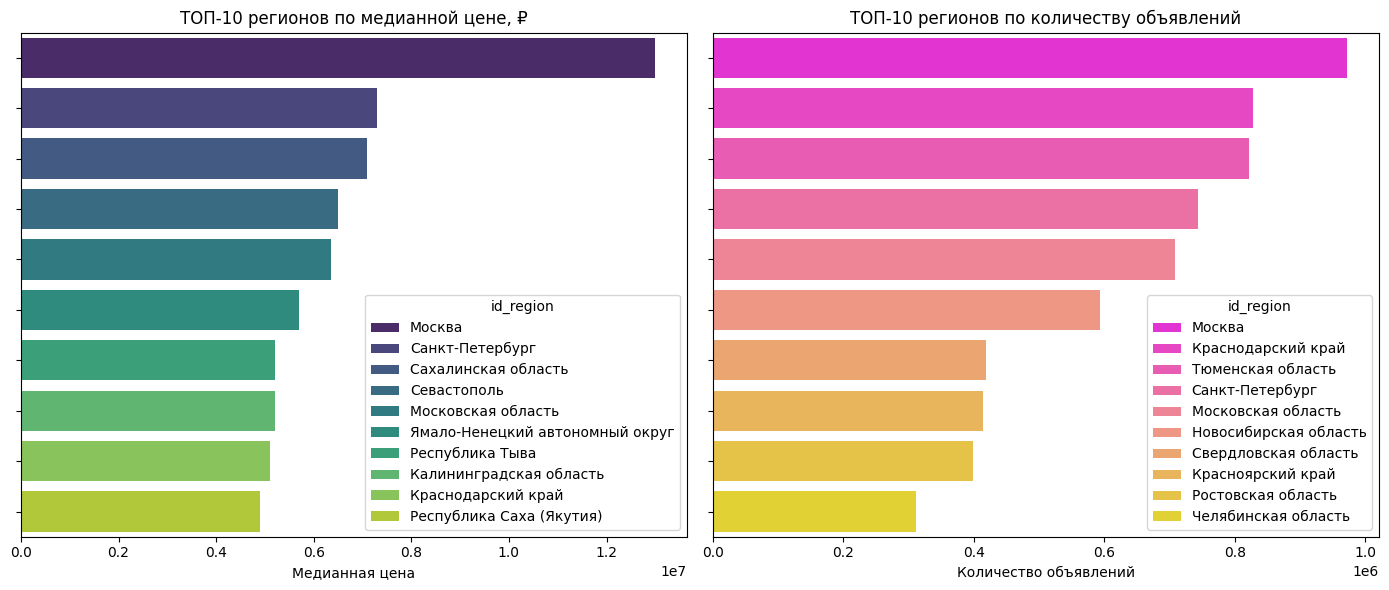

In [27]:
region_median_named = df.groupby('id_region')['price'].median().sort_values(ascending = False).rename(index = get_region_name)
region_count_named = df['id_region'].value_counts().rename(index = get_region_name)

fig, axes = plt.subplots(1, 2, figsize = (14, 6))

# Медианная цена
top_prices = region_median_named.head(10)
sns.barplot(x = top_prices.values, y = top_prices.index, hue = top_prices.index, ax = axes[0], palette = 'viridis', legend = True)
axes[0].set_title('ТОП-10 регионов по медианной цене, ₽')
axes[0].set_xlabel('Медианная цена')
axes[0].set_ylabel('')
axes[0].set_yticklabels([])

# Количество объявлений
top_counts = region_count_named.head(10)
sns.barplot(x = top_counts.values, y = top_counts.index, hue = top_counts.index, ax = axes[1], palette = 'spring', legend = True )
axes[1].set_title('ТОП-10 регионов по количеству объявлений')
axes[1].set_xlabel('Количество объявлений')
axes[1].set_ylabel('')
axes[1].set_yticklabels([])

plt.tight_layout()
plt.show()

Структура рынка не изменилась, удалось избавиться от мусорных данных и дубликатов, сохранив прежнее строение данных.

### Создаем фичи

Создаем стоимость квадрата, что порой лучше описывает ситуацию на рынке, так же вместо этажности используем соотношение этажа к общей этажности и логарифмируем цену, так как установили, что у нас хорошо ложится случайная величина под логнорм распределе/ние.

In [28]:
df['price_per_sqm'] = df['price'] / df['area']

df['floor_ratio'] = df['level'] / df['levels'].replace(0, 1)
df['floor_ratio'] = df['floor_ratio'].clip(0, 1)  

df['price_log'] = np.log(df['price'])

In [29]:
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
numeric_cols.remove('price')

print("Числовые колонки для корреляции с ценой:")
print(numeric_cols)

corr_with_price = df[numeric_cols + ['price']].corr()['price'].sort_values(ascending = False)

print("\nКОРРЕЛЯЦИЯ С ЦЕНОЙ\n")
print(corr_with_price)

Числовые колонки для корреляции с ценой:
['level', 'levels', 'rooms', 'area', 'kitchen_area', 'geo_lat', 'geo_lon', 'building_type', 'object_type', 'id_region', 'price_per_sqm', 'floor_ratio', 'price_log']

КОРРЕЛЯЦИЯ С ЦЕНОЙ

price            1.00
price_per_sqm    0.94
price_log        0.06
area             0.04
kitchen_area     0.02
rooms            0.02
id_region        0.01
levels           0.01
level            0.01
geo_lat          0.00
object_type      0.00
floor_ratio      0.00
building_type   -0.00
geo_lon         -0.01
Name: price, dtype: float64


В итоге признак цены квадратного метра оказался линейно зависимым, что логично, поэтому использовать его не целесообразно. 

In [30]:
level_corr = df[['level', 'levels', 'floor_ratio']].corr()
print("Корреляция между признаками этажности:")
print(level_corr)

Корреляция между признаками этажности:
             level  levels  floor_ratio
level         1.00    0.67         0.51
levels        0.67    1.00        -0.16
floor_ratio   0.51   -0.16         1.00


Оставляем только __levels__ и __floor_ratio__

In [31]:
df.drop(columns = ['price_per_sqm', 'level'], inplace = True)
df

,date,price,levels,rooms,area,kitchen_area,geo_lat,geo_lon,building_type,object_type,id_region,floor_ratio,price_log
0,2021-01-01,2451300,31,1,30.30,8.40,56.78,60.70,0,2,66,0.48,14.71
1,2021-01-01,1450000,5,1,33.00,6.00,44.61,40.14,0,0,1,1.00,14.19
2,2021-01-01,10700000,13,3,85.00,12.00,55.54,37.73,3,0,50,0.31,16.19
3,2021-01-01,3100000,5,3,82.00,9.00,44.61,40.14,0,0,1,0.60,14.95
4,2021-01-01,2500000,3,1,30.00,9.00,44.74,37.71,3,2,23,0.67,14.73
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11358145,2021-12-31,6099000,9,3,65.00,10.00,56.04,92.75,0,0,24,0.44,15.62
11358146,2021-12-31,2490000,10,2,56.90,10.00,55.17,61.52,0,0,74,0.10,14.73
11358147,2021-12-31,850000,2,2,37.00,5.00,55.95,43.09,0,0,52,1.00,13.65
11358148,2021-12-31,4360000,5,1,36.00,9.00,61.26,73.44,0,0,86,1.00,15.29


In [32]:
df['date'] = pd.to_datetime(df['date'])

df['month'] = df['date'].dt.month        
df['quarter'] = df['date'].dt.quarter    
df['season'] = df['date'].dt.month % 12 // 3 + 1  
df['day_of_week'] = df['date'].dt.dayofweek  

features = ['area', 'rooms', 'kitchen_area', 'levels', 'floor_ratio', 
            'building_type', 'object_type', 'id_region', 
            'month', 'quarter', 'day_of_week']
df.drop(columns = ['date'], inplace = True)

In [33]:
df

,price,levels,rooms,area,kitchen_area,geo_lat,geo_lon,building_type,object_type,id_region,floor_ratio,price_log,month,quarter,season,day_of_week
0,2451300,31,1,30.30,8.40,56.78,60.70,0,2,66,0.48,14.71,1,1,1,4
1,1450000,5,1,33.00,6.00,44.61,40.14,0,0,1,1.00,14.19,1,1,1,4
2,10700000,13,3,85.00,12.00,55.54,37.73,3,0,50,0.31,16.19,1,1,1,4
3,3100000,5,3,82.00,9.00,44.61,40.14,0,0,1,0.60,14.95,1,1,1,4
4,2500000,3,1,30.00,9.00,44.74,37.71,3,2,23,0.67,14.73,1,1,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11358145,6099000,9,3,65.00,10.00,56.04,92.75,0,0,24,0.44,15.62,12,4,1,4
11358146,2490000,10,2,56.90,10.00,55.17,61.52,0,0,74,0.10,14.73,12,4,1,4
11358147,850000,2,2,37.00,5.00,55.95,43.09,0,0,52,1.00,13.65,12,4,1,4
11358148,4360000,5,1,36.00,9.00,61.26,73.44,0,0,86,1.00,15.29,12,4,1,4


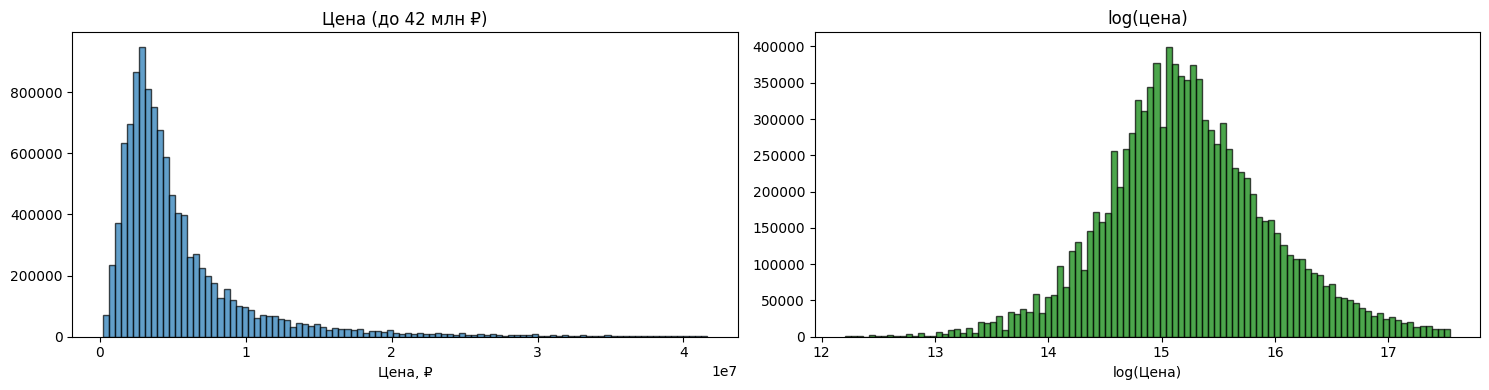

In [34]:
fig, axes = plt.subplots(1, 2, figsize = (15, 4))

price_99 = df['price'].quantile(0.99)
axes[0].hist(df[df['price'] <= price_99]['price'], bins = 100, edgecolor = 'black', alpha = 0.7)
axes[0].set_title(f'Цена (до {price_99/1e6:.0f} млн ₽)')
axes[0].set_xlabel('Цена, ₽')

axes[1].hist(df[df['price'] <= price_99]['price_log'], bins = 100, edgecolor = 'black', alpha = 0.7, color = 'green')
axes[1].set_title('log(цена)')
axes[1].set_xlabel('log(Цена)')

plt.tight_layout()
plt.show()

In [70]:
df

,price,levels,rooms,area,kitchen_area,geo_lat,geo_lon,building_type,object_type,id_region,floor_ratio,price_log,month,quarter,season,day_of_week
0,2451300,31,1,30.30,8.40,56.78,60.70,0,2,66,0.48,14.71,1,1,1,4
1,1450000,5,1,33.00,6.00,44.61,40.14,0,0,1,1.00,14.19,1,1,1,4
2,10700000,13,3,85.00,12.00,55.54,37.73,3,0,50,0.31,16.19,1,1,1,4
3,3100000,5,3,82.00,9.00,44.61,40.14,0,0,1,0.60,14.95,1,1,1,4
4,2500000,3,1,30.00,9.00,44.74,37.71,3,2,23,0.67,14.73,1,1,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11358145,6099000,9,3,65.00,10.00,56.04,92.75,0,0,24,0.44,15.62,12,4,1,4
11358146,2490000,10,2,56.90,10.00,55.17,61.52,0,0,74,0.10,14.73,12,4,1,4
11358147,850000,2,2,37.00,5.00,55.95,43.09,0,0,52,1.00,13.65,12,4,1,4
11358148,4360000,5,1,36.00,9.00,61.26,73.44,0,0,86,1.00,15.29,12,4,1,4


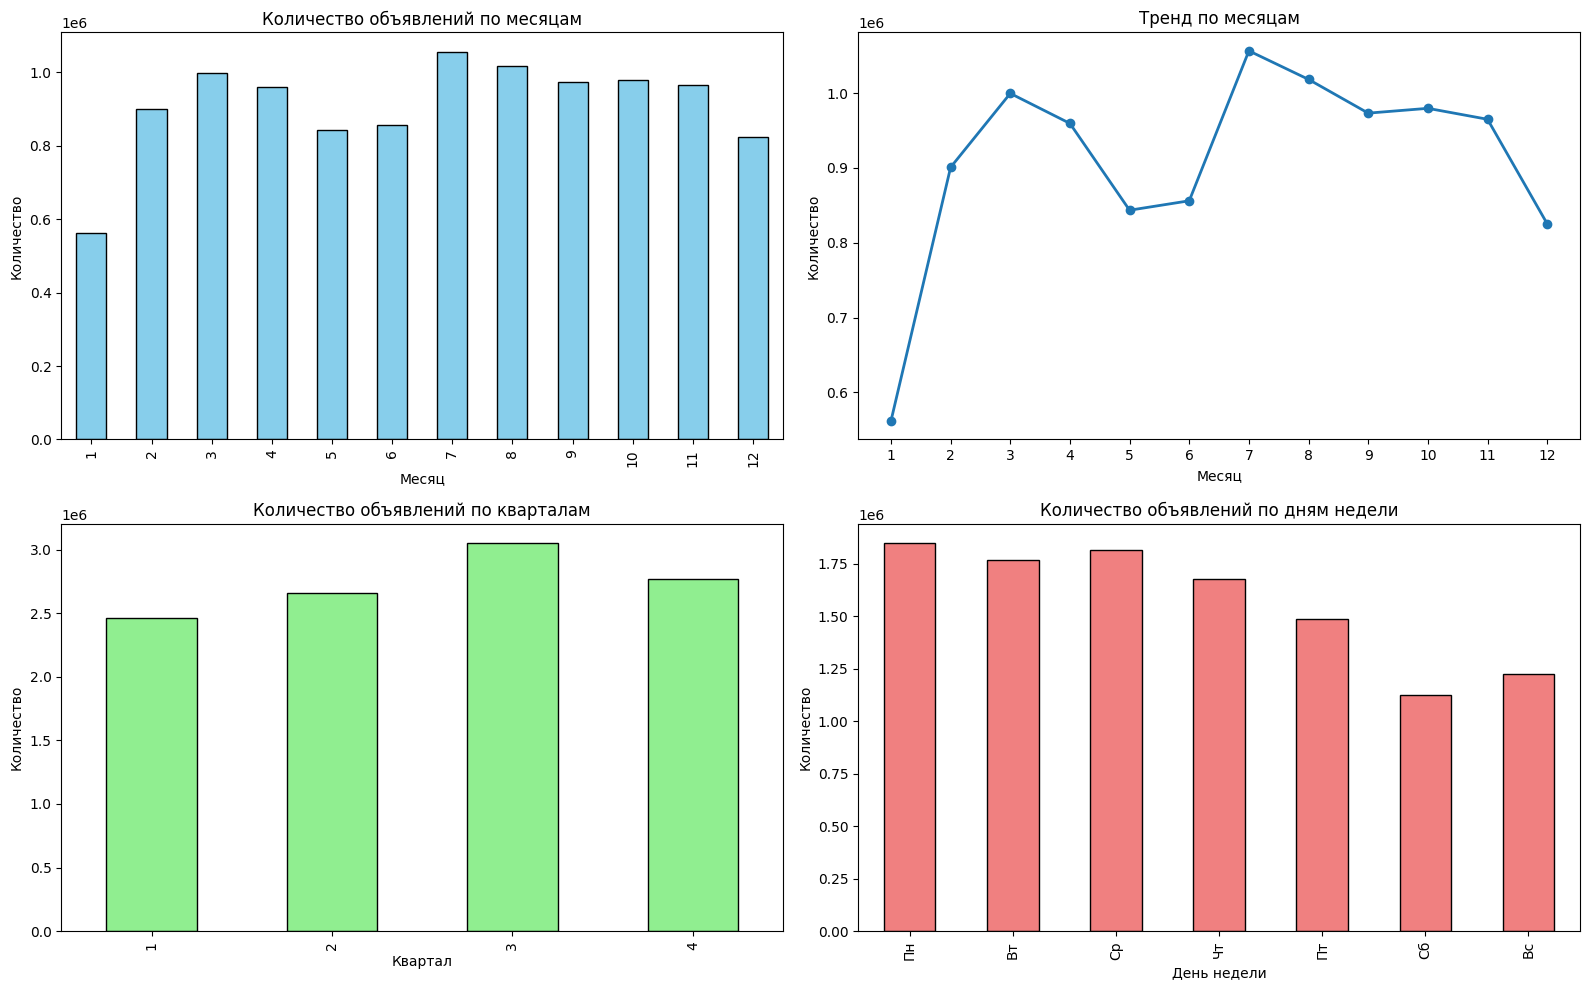

In [75]:
weekday_names = {0: 'Пн', 1: 'Вт', 2: 'Ср', 3: 'Чт', 4: 'Пт', 5: 'Сб', 6: 'Вс'}
season_names = {1: 'Зима', 2: 'Весна', 3: 'Лето', 4: 'Осень'}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

monthly_counts = df.groupby('month').size()
monthly_counts.plot(kind = 'bar', ax = axes[0, 0], color = 'skyblue', edgecolor = 'black')
axes[0, 0].set_title('Количество объявлений по месяцам')
axes[0, 0].set_xlabel('Месяц')
axes[0, 0].set_ylabel('Количество')

monthly_counts.plot(kind = 'line', marker = 'o', ax = axes[0, 1], linewidth = 2)
axes[0, 1].set_title('Тренд по месяцам')
axes[0, 1].set_xlabel('Месяц')
axes[0, 1].set_ylabel('Количество')
axes[0, 1].set_xticks(range(1, 13))

quarterly_counts = df.groupby('quarter').size()
quarterly_counts.plot(kind = 'bar', ax = axes[1, 0], color = 'lightgreen', edgecolor = 'black')
axes[1, 0].set_title('Количество объявлений по кварталам')
axes[1, 0].set_xlabel('Квартал')
axes[1, 0].set_ylabel('Количество')

daily_counts = df.groupby('day_of_week').size()
daily_counts.index = [weekday_names[x] for x in daily_counts.index]
daily_counts = daily_counts.reindex(['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс'])
daily_counts.plot(kind = 'bar', ax = axes[1, 1], color = 'lightcoral', edgecolor = 'black')
axes[1, 1].set_title('Количество объявлений по дням недели')
axes[1, 1].set_xlabel('День недели')
axes[1, 1].set_ylabel('Количество')

plt.tight_layout()
plt.show()

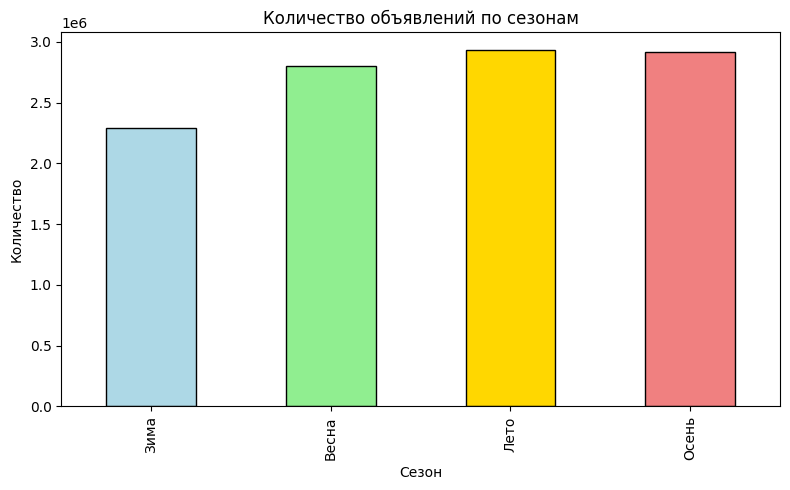

In [73]:
fig, ax = plt.subplots(figsize=(8, 5))
season_counts = df.groupby('season').size()
season_counts.index = [season_names[x] for x in season_counts.index]
season_counts.plot(kind='bar', ax=ax, color=['lightblue', 'lightgreen', 'gold', 'lightcoral'], edgecolor='black')
ax.set_title('Количество объявлений по сезонам')
ax.set_xlabel('Сезон')
ax.set_ylabel('Количество')
plt.tight_layout()
plt.show()

### Обучение моделей 

In [35]:
features = ['area', 'rooms', 'kitchen_area', 'levels', 'floor_ratio', 
            'building_type', 'object_type', 'id_region',
            'month', 'quarter', 'season', 'day_of_week']

X = df[features]
y = df['price_log'] 

X_train, X_val_test, y_train, y_val_test = train_test_split(X, y, test_size = 0.3, random_state = 42, shuffle = True)
X_val, X_test, y_val, y_test = train_test_split(X_val_test, y_val_test, test_size = 0.4, random_state = 42, shuffle = True)
y_test = np.exp(y_test)
y_val = np.exp(y_val)

In [36]:
def exp_pred(y_pred_log):
    return np.exp(y_pred_log)

In [37]:
results_summary = pd.DataFrame(columns = [
    'model_name',
    'train_time_sec',
    'predict_time_sec',
    'val_r2',
    'val_mape',
    'test_r2',
    'test_mape',
    'best_params'
])

def save_model_results(model_name, train_time, predict_time, val_r2, val_mape, test_r2, test_mape, best_params = None):
    global results_summary
    
    new_row = pd.DataFrame([{
        'model_name': model_name,
        'train_time_sec': round(train_time, 2),
        'predict_time_sec': round(predict_time, 4),
        'val_r2': round(val_r2, 4),
        'val_mape': round(val_mape, 2),
        'test_r2': round(test_r2, 4),
        'test_mape': round(test_mape, 2),
        'best_params': str(best_params) if best_params else None
    }])
    
    results_summary = pd.concat([results_summary, new_row], ignore_index = True)
    print(f"✅ Результаты для {model_name} сохранены")

#### ЛИНЕЙНАЯ РЕГРЕССИЯ

In [38]:
start_train = time.time()
lr = LinearRegression(n_jobs=-1)
lr.fit(X_train, y_train)
train_time = time.time() - start_train

start_predict = time.time()
y_pred_val_log = lr.predict(X_val)
y_pred_test_log = lr.predict(X_test)
predict_time = time.time() - start_predict

y_pred_val = exp_pred(y_pred_val_log)
y_pred_test = exp_pred(y_pred_test_log)

val_r2 = r2_score(y_val, y_pred_val)
val_mape = mean_absolute_percentage_error(y_val, y_pred_val) * 100
test_r2 = r2_score(y_test, y_pred_test)
test_mape = mean_absolute_percentage_error(y_test, y_pred_test) * 100

save_model_results(
    model_name = 'Linear Regression',
    train_time = train_time,
    predict_time = predict_time,
    val_r2 = val_r2,
    val_mape = val_mape,
    test_r2 = test_r2,
    test_mape = test_mape
)

✅ Результаты для Linear Regression сохранены


C:\Users\bublX\AppData\Local\Temp\ipykernel_16068\4146791389.py:26: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_summary = pd.concat([results_summary, new_row], ignore_index = True)


In [39]:
print(f"\nVALIDATION:")
print(f"  R²: {val_r2:.4f}")
print(f"  MAPE: {val_mape:.2f}%")

print(f"\nTEST:")
print(f"  R²: {test_r2:.4f}")
print(f"  MAPE: {test_mape:.2f}%")

print(f"\n⏱️ ВРЕМЯ:")
print(f"  Обучение: {train_time:.2f} сек")
print(f"  Предсказание: {predict_time:.4f} сек")


VALIDATION:
  R²: -0.3613
  MAPE: 50.65%

TEST:
  R²: -0.4140
  MAPE: 49.89%

⏱️ ВРЕМЯ:
  Обучение: 2.02 сек
  Предсказание: 0.1540 сек


#### LASSO

In [40]:
lasso_params = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]}
lasso = Lasso(random_state = 42, max_iter = 10000)

start_train = time.time()
lasso_grid = GridSearchCV(lasso, lasso_params, cv = 5, scoring = 'neg_mean_absolute_percentage_error', n_jobs = 1)
lasso_grid.fit(X_train, y_train)
train_time = time.time() - start_train

start_predict = time.time()
y_pred_val_log = lasso_grid.predict(X_val)
y_pred_test_log = lasso_grid.predict(X_test)
predict_time = time.time() - start_predict

y_pred_val = exp_pred(y_pred_val_log)
y_pred_test = exp_pred(y_pred_test_log)

val_r2 = r2_score(y_val, y_pred_val)
val_mape = mean_absolute_percentage_error(y_val, y_pred_val) * 100
test_r2 = r2_score(y_test, y_pred_test)
test_mape = mean_absolute_percentage_error(y_test, y_pred_test) * 100

save_model_results(
    model_name = 'Linear Regression + LASSO',
    train_time = train_time,
    predict_time = predict_time,
    val_r2 = val_r2,
    val_mape = val_mape,
    test_r2 = test_r2,
    test_mape = test_mape
)

✅ Результаты для Linear Regression + LASSO сохранены


In [41]:
print(f"\nЛучшая alpha: {lasso_grid.best_params_['alpha']}")
print(f"Лучший score на кросс-валидации: {lasso_grid.best_score_:.4f}")

print(f"\nVALIDATION:")
print(f"  R²: {val_r2:.4f}")
print(f"  MAPE: {val_mape:.2f}%")

print(f"\nTEST:")
print(f"  R²: {test_r2:.4f}")
print(f"  MAPE: {test_mape:.2f}%")

print(f"\n⏱️ ВРЕМЯ:")
print(f"  Обучение (GridSearchCV): {train_time:.2f} сек")
print(f"  Предсказание: {predict_time:.4f} сек")


Лучшая alpha: 0.0001
Лучший score на кросс-валидации: -0.0278

VALIDATION:
  R²: -0.3603
  MAPE: 50.64%

TEST:
  R²: -0.4128
  MAPE: 49.88%

⏱️ ВРЕМЯ:
  Обучение (GridSearchCV): 127.46 сек
  Предсказание: 0.1530 сек


#### RIDGE

In [42]:
ridge_params = {'alpha': [0.01, 0.1, 1, 10, 50, 100, 500]}
ridge = Ridge(random_state = 42)

start_train = time.time()
ridge_grid = GridSearchCV(ridge, ridge_params, cv = 5, scoring = 'neg_mean_absolute_percentage_error', n_jobs = 1)
ridge_grid.fit(X_train, y_train)
train_time = time.time() - start_train

start_predict = time.time()
y_pred_val_log = ridge_grid.predict(X_val)
y_pred_test_log = ridge_grid.predict(X_test)
predict_time = time.time() - start_predict

y_pred_val = exp_pred(y_pred_val_log)
y_pred_test = exp_pred(y_pred_test_log)

val_r2 = r2_score(y_val, y_pred_val)
val_mape = mean_absolute_percentage_error(y_val, y_pred_val) * 100
test_r2 = r2_score(y_test, y_pred_test)
test_mape = mean_absolute_percentage_error(y_test, y_pred_test) * 100

save_model_results(
    model_name = 'Linear Regression + RIDGE',
    train_time = train_time,
    predict_time = predict_time,
    val_r2 = val_r2,
    val_mape = val_mape,
    test_r2 = test_r2,
    test_mape = test_mape
)

✅ Результаты для Linear Regression + RIDGE сохранены


In [43]:
print(f"\nЛучшая alpha: {ridge_grid.best_params_['alpha']}")
print(f"Лучший score на кросс-валидации: {ridge_grid.best_score_:.4f}")

print(f"\nVALIDATION:")
print(f"  R²: {val_r2:.4f}")
print(f"  MAPE: {val_mape:.2f}%")

print(f"\nTEST:")
print(f"  R²: {test_r2:.4f}")
print(f"  MAPE: {test_mape:.2f}%")

print(f"\n⏱️ ВРЕМЯ:")
print(f"  Обучение (GridSearchCV): {train_time:.2f} сек")
print(f"  Предсказание: {predict_time:.4f} сек")


Лучшая alpha: 500
Лучший score на кросс-валидации: -0.0278

VALIDATION:
  R²: -0.3613
  MAPE: 50.65%

TEST:
  R²: -0.4140
  MAPE: 49.89%

⏱️ ВРЕМЯ:
  Обучение (GridSearchCV): 42.08 сек
  Предсказание: 0.1520 сек


#### CatBoost

In [120]:
param_dist = {
    'iterations': [300, 500, 700],
    'depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.07, 0.1],
    'l2_leaf_reg': [1, 3, 5, 7, 9],
    'border_count': [32, 64, 128, 255],
    'bagging_temperature': [0, 0.5, 1],
    'random_strength': [0.5, 1, 2]
}

catboost = CatBoostRegressor(
    random_seed = 42,
    verbose = 0
)

start_train = time.time()
catboost_random = RandomizedSearchCV(
    estimator = catboost,
    param_distributions = param_dist,
    n_iter = 20,
    cv = 3,
    scoring = 'neg_mean_absolute_percentage_error',
    n_jobs = 1,
    random_state = 42,
    verbose = 2
)
catboost_random.fit(X_train, y_train)
train_time = time.time() - start_train

start_predict = time.time()
y_pred_val_log = catboost_random.predict(X_val)
y_pred_test_log = catboost_random.predict(X_test)
predict_time = time.time() - start_predict

y_pred_val = np.exp(y_pred_val_log)
y_pred_test = np.exp(y_pred_test_log)

val_r2 = r2_score(y_val, y_pred_val)
val_mape = mean_absolute_percentage_error(y_val, y_pred_val) * 100
test_r2 = r2_score(y_test, y_pred_test)
test_mape = mean_absolute_percentage_error(y_test, y_pred_test) * 100

save_model_results(
    model_name = 'CatBoost',
    train_time = train_time,
    predict_time = predict_time,
    val_r2 = val_r2,
    val_mape = val_mape,
    test_r2 = test_r2,
    test_mape = test_mape,
    best_params = catboost_random.best_params_
)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END bagging_temperature=1, border_count=32, depth=4, iterations=300, l2_leaf_reg=9, learning_rate=0.07, random_strength=1; total time=  55.0s
[CV] END bagging_temperature=1, border_count=32, depth=4, iterations=300, l2_leaf_reg=9, learning_rate=0.07, random_strength=1; total time=  54.1s
[CV] END bagging_temperature=1, border_count=32, depth=4, iterations=300, l2_leaf_reg=9, learning_rate=0.07, random_strength=1; total time=  53.9s
[CV] END bagging_temperature=0, border_count=32, depth=10, iterations=700, l2_leaf_reg=5, learning_rate=0.03, random_strength=2; total time= 4.0min
[CV] END bagging_temperature=0, border_count=32, depth=10, iterations=700, l2_leaf_reg=5, learning_rate=0.03, random_strength=2; total time= 4.0min
[CV] END bagging_temperature=0, border_count=32, depth=10, iterations=700, l2_leaf_reg=5, learning_rate=0.03, random_strength=2; total time= 4.0min
[CV] END bagging_temperature=0.5, border_count=64, dep

In [121]:
print(f"\nЛучшие параметры:")
for param, value in catboost_random.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nЛучший score на кросс-валидации: {catboost_random.best_score_:.4f}")

print(f"\nVALIDATION:")
print(f"  R²: {val_r2:.4f}")
print(f"  MAPE: {val_mape:.2f}%")

print(f"\nTEST:")
print(f"  R²: {test_r2:.4f}")
print(f"  MAPE: {test_mape:.2f}%")

print(f"\n⏱️ ВРЕМЯ:")
print(f"  Обучение (RandomizedSearchCV): {train_time:.2f} сек")
print(f"  Предсказание: {predict_time:.4f} сек")


Лучшие параметры:
  random_strength: 1
  learning_rate: 0.07
  l2_leaf_reg: 5
  iterations: 700
  depth: 10
  border_count: 128
  bagging_temperature: 0.5

Лучший score на кросс-валидации: -0.0146

VALIDATION:
  R²: 0.0573
  MAPE: 23.80%

TEST:
  R²: 0.0625
  MAPE: 23.84%

⏱️ ВРЕМЯ:
  Обучение (RandomizedSearchCV): 9537.53 сек
  Предсказание: 3.5921 сек


In [44]:
best_params = {
    'random_strength': 1,
    'learning_rate': 0.07,
    'l2_leaf_reg': 5,
    'iterations': 700,
    'depth': 10,
    'border_count': 128,
    'bagging_temperature': 0.5
}

start_train = time.time()

final_catboost = CatBoostRegressor(
    **best_params,
    random_seed = 42,
    verbose = 50
)

final_catboost.fit(X_train, y_train)
train_time = time.time() - start_train

start_predict = time.time()
y_pred_val_log = final_catboost.predict(X_val)
y_pred_test_log = final_catboost.predict(X_test)
predict_time = time.time() - start_predict

y_pred_val = np.exp(y_pred_val_log)
y_pred_test = np.exp(y_pred_test_log)

val_r2 = r2_score(y_val, y_pred_val)
val_mape = mean_absolute_percentage_error(y_val, y_pred_val) * 100
test_r2 = r2_score(y_test, y_pred_test)
test_mape = mean_absolute_percentage_error(y_test, y_pred_test) * 100

0:	learn: 0.7526081	total: 771ms	remaining: 8m 59s
50:	learn: 0.3704055	total: 28.8s	remaining: 6m 6s
100:	learn: 0.3483412	total: 57.4s	remaining: 5m 40s
150:	learn: 0.3390749	total: 1m 25s	remaining: 5m 10s
200:	learn: 0.3335341	total: 1m 53s	remaining: 4m 41s
250:	learn: 0.3299838	total: 2m 21s	remaining: 4m 13s
300:	learn: 0.3272174	total: 2m 49s	remaining: 3m 44s
350:	learn: 0.3251123	total: 3m 17s	remaining: 3m 16s
400:	learn: 0.3233428	total: 3m 45s	remaining: 2m 48s
450:	learn: 0.3219678	total: 4m 13s	remaining: 2m 19s
500:	learn: 0.3208243	total: 4m 41s	remaining: 1m 51s
550:	learn: 0.3197755	total: 5m 9s	remaining: 1m 23s
600:	learn: 0.3187830	total: 5m 37s	remaining: 55.6s
650:	learn: 0.3179045	total: 6m 5s	remaining: 27.5s
699:	learn: 0.3171196	total: 6m 33s	remaining: 0us


In [49]:
param_dist_xgb = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.07, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [0, 0.1, 1]
}

xgb = XGBRegressor(random_state = 42, verbosity = 0, n_jobs = 1)

start_train = time.time()
xgb_random = RandomizedSearchCV(
    estimator = xgb,
    param_distributions = param_dist_xgb,
    n_iter = 20,
    cv = 3,
    scoring = 'neg_mean_absolute_percentage_error',
    n_jobs = 1,
    random_state = 42,
    verbose = 2
)
xgb_random.fit(X_train, y_train)
train_time = time.time() - start_train

start_predict = time.time()
y_pred_val_log = xgb_random.predict(X_val)
y_pred_test_log = xgb_random.predict(X_test)
predict_time = time.time() - start_predict

y_pred_val = np.exp(y_pred_val_log)
y_pred_test = np.exp(y_pred_test_log)

val_r2 = r2_score(y_val, y_pred_val)
val_mape = mean_absolute_percentage_error(y_val, y_pred_val) * 100
test_r2 = r2_score(y_test, y_pred_test)
test_mape = mean_absolute_percentage_error(y_test, y_pred_test) * 100

save_model_results(
    model_name = 'XGBoost',
    train_time = train_time,
    predict_time = predict_time,
    val_r2 = val_r2,
    val_mape = val_mape,
    test_r2 = test_r2,
    test_mape = test_mape,
    best_params = xgb_random.best_params_
)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END colsample_bytree=0.6, learning_rate=0.03, max_depth=10, n_estimators=500, reg_alpha=1, reg_lambda=0.1, subsample=1.0; total time= 6.4min
[CV] END colsample_bytree=0.6, learning_rate=0.03, max_depth=10, n_estimators=500, reg_alpha=1, reg_lambda=0.1, subsample=1.0; total time= 6.5min
[CV] END colsample_bytree=0.6, learning_rate=0.03, max_depth=10, n_estimators=500, reg_alpha=1, reg_lambda=0.1, subsample=1.0; total time= 6.4min
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=6, n_estimators=500, reg_alpha=0.1, reg_lambda=1, subsample=1.0; total time= 2.8min
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=6, n_estimators=500, reg_alpha=0.1, reg_lambda=1, subsample=1.0; total time= 2.9min
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=6, n_estimators=500, reg_alpha=0.1, reg_lambda=1, subsample=1.0; total time= 2.9min
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=4, n_

In [50]:
save_model_results(
    model_name = 'XGBoost',
    train_time = train_time,
    predict_time = predict_time,
    val_r2 = val_r2,
    val_mape = val_mape,
    test_r2 = test_r2,
    test_mape = test_mape,
    best_params = xgb_random.best_params_
)

print(f"\nЛучшие параметры:")
for param, value in xgb_random.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nЛучший score: {xgb_random.best_score_:.4f}")
print(f"\nVALIDATION: R²={val_r2:.4f}, MAPE={val_mape:.2f}%")
print(f"TEST: R²={test_r2:.4f}, MAPE={test_mape:.2f}%")
print(f"⏱️ Обучение: {train_time:.2f} сек, Предсказание: {predict_time:.4f} сек")

✅ Результаты для XGBoost сохранены

Лучшие параметры:
  subsample: 0.6
  reg_lambda: 1
  reg_alpha: 0.1
  n_estimators: 500
  max_depth: 10
  learning_rate: 0.05
  colsample_bytree: 0.8

Лучший score: -0.0138

VALIDATION: R²=0.0627, MAPE=22.39%
TEST: R²=0.0705, MAPE=22.43%
⏱️ Обучение: 10698.25 сек, Предсказание: 56.6684 сек


In [51]:
param_dist_lgb = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.07, 0.1],
    'num_leaves': [15, 31, 63],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [0, 0.1, 1]
}

lgb = LGBMRegressor(random_state = 42, verbose = -1, n_jobs = 1)

start_train = time.time()
lgb_random = RandomizedSearchCV(
    estimator = lgb,
    param_distributions = param_dist_lgb,
    n_iter = 20,
    cv = 3,
    scoring = 'neg_mean_absolute_percentage_error',
    n_jobs = 1,
    random_state = 42,
    verbose = 2
)
lgb_random.fit(X_train, y_train)
train_time = time.time() - start_train

start_predict = time.time()
y_pred_val_log = lgb_random.predict(X_val)
y_pred_test_log = lgb_random.predict(X_test)
predict_time = time.time() - start_predict

y_pred_val = np.exp(y_pred_val_log)
y_pred_test = np.exp(y_pred_test_log)

val_r2 = r2_score(y_val, y_pred_val)
val_mape = mean_absolute_percentage_error(y_val, y_pred_val) * 100
test_r2 = r2_score(y_test, y_pred_test)
test_mape = mean_absolute_percentage_error(y_test, y_pred_test) * 100

save_model_results(
    model_name = 'LightGBM',
    train_time = train_time,
    predict_time = predict_time,
    val_r2 = val_r2,
    val_mape = val_mape,
    test_r2 = test_r2,
    test_mape = test_mape,
    best_params = lgb_random.best_params_
)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=4, n_estimators=500, num_leaves=15, reg_alpha=0, reg_lambda=0, subsample=0.6; total time= 2.6min
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=4, n_estimators=500, num_leaves=15, reg_alpha=0, reg_lambda=0, subsample=0.6; total time= 2.7min
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=4, n_estimators=500, num_leaves=15, reg_alpha=0, reg_lambda=0, subsample=0.6; total time= 2.6min
[CV] END colsample_bytree=0.6, learning_rate=0.01, max_depth=8, n_estimators=300, num_leaves=31, reg_alpha=1, reg_lambda=0.1, subsample=1.0; total time= 2.6min
[CV] END colsample_bytree=0.6, learning_rate=0.01, max_depth=8, n_estimators=300, num_leaves=31, reg_alpha=1, reg_lambda=0.1, subsample=1.0; total time= 2.6min
[CV] END colsample_bytree=0.6, learning_rate=0.01, max_depth=8, n_estimators=300, num_leaves=31, reg_alpha=1, reg_lambda=0.1, subsample=1.0; tota

In [52]:
print(f"\nЛучшие параметры:")
for param, value in lgb_random.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nЛучший score: {lgb_random.best_score_:.4f}")
print(f"\nVALIDATION: R²={val_r2:.4f}, MAPE={val_mape:.2f}%")
print(f"TEST: R²={test_r2:.4f}, MAPE={test_mape:.2f}%")
print(f"⏱️ Обучение: {train_time:.2f} сек, Предсказание: {predict_time:.4f} сек")


Лучшие параметры:
  subsample: 0.6
  reg_lambda: 1
  reg_alpha: 1
  num_leaves: 63
  n_estimators: 300
  max_depth: 10
  learning_rate: 0.1
  colsample_bytree: 0.6

Лучший score: -0.0147

VALIDATION: R²=0.0611, MAPE=23.98%
TEST: R²=0.0671, MAPE=24.02%
⏱️ Обучение: 39029.44 сек, Предсказание: 73.5071 сек


In [56]:
os.makedirs('models', exist_ok = True)


def save_final_model(model, model_name, val_r2, val_mape, test_r2, test_mape, train_time, predict_time, best_params):
    """Универсальное сохранение модели с метаданными"""
    
    joblib.dump(model, f'models/{model_name.lower()}_best.pkl')
    print(f"✅ {model_name} сохранён: models/{model_name.lower()}_best.pkl")
    
    model_info = {
        'model_name': model_name,
        'features': X_train.columns.tolist(),
        'best_params': best_params,
        'val_r2': val_r2,
        'val_mape': val_mape,
        'test_r2': test_r2,
        'test_mape': test_mape,
        'train_time_sec': train_time,
        'predict_time_sec': predict_time,
        'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'train_size': len(X_train)
    }
    joblib.dump(model_info, f'models/{model_name.lower()}_info.pkl')
    print(f"✅ Метаданные сохранены: models/{model_name.lower()}_info.pkl")


save_final_model(
    model = final_catboost,
    model_name = 'CatBoost',
    val_r2 = val_r2,
    val_mape = val_mape,
    test_r2 = test_r2,
    test_mape = test_mape,
    train_time = train_time,
    predict_time = predict_time,
    best_params = best_params
)

save_final_model(
    model = xgb_random.best_estimator_,
    model_name = 'XGBoost',
    val_r2 = val_r2,
    val_mape = val_mape,
    test_r2 = test_r2,
    test_mape = test_mape,
    train_time = train_time,
    predict_time = predict_time,
    best_params = xgb_random.best_params_
)

save_final_model(
    model = lgb_random.best_estimator_,
    model_name = 'LightGBM',
    val_r2 = val_r2,
    val_mape = val_mape,
    test_r2 = test_r2,
    test_mape = test_mape,
    train_time = train_time,
    predict_time = predict_time,
    best_params = lgb_random.best_params_
)

joblib.dump(X_train.columns.tolist(), 'models/feature_names.pkl')

✅ CatBoost сохранён: models/catboost_best.pkl
✅ Метаданные сохранены: models/catboost_info.pkl
✅ XGBoost сохранён: models/xgboost_best.pkl
✅ Метаданные сохранены: models/xgboost_info.pkl
✅ LightGBM сохранён: models/lightgbm_best.pkl
✅ Метаданные сохранены: models/lightgbm_info.pkl


['models/feature_names.pkl']

In [64]:
xgb_random.best_estimator_.set_params(verbosity = 1) 
lgb_random.best_estimator_.set_params(verbosity = 1) 

base_models = [
    ('catboost', final_catboost),
    ('xgboost', xgb_random.best_estimator_),
    ('lightgbm', lgb_random.best_estimator_)
]

In [65]:
meta_model = Ridge(alpha = 1.0)
stacking_model = StackingRegressor(
    estimators = base_models,
    final_estimator = meta_model,
    cv = 'prefit',
    n_jobs = 1,
    verbose = 2
)

start_train = time.time()
stacking_model.fit(X_train, y_train)
train_time = time.time() - start_train

start_predict = time.time()
y_pred_val_log = stacking_model.predict(X_val)
y_pred_test_log = stacking_model.predict(X_test)
predict_time = time.time() - start_predict

y_pred_val = np.exp(y_pred_val_log)
y_pred_test = np.exp(y_pred_test_log)

val_r2_st = r2_score(y_val, y_pred_val)
val_mape_st = mean_absolute_percentage_error(y_val, y_pred_val) * 100
test_r2_st = r2_score(y_test, y_pred_test)
test_mape_st = mean_absolute_percentage_error(y_test, y_pred_test) * 100

save_model_results(
    model_name = 'Stacking (CB+XGB+LGB)',
    train_time = train_time,
    predict_time = predict_time,
    val_r2 = val_r2_st,
    val_mape = val_mape_st,
    test_r2 = test_r2_st,
    test_mape = test_mape_st
)

[LightGBM] [Warning] verbosity is set=1, verbose=-1 will be ignored. Current value: verbosity=1
[LightGBM] [Warning] verbosity is set=1, verbose=-1 will be ignored. Current value: verbosity=1
[LightGBM] [Warning] verbosity is set=1, verbose=-1 will be ignored. Current value: verbosity=1
✅ Результаты для Stacking (CB+XGB+LGB) сохранены


In [66]:
joblib.dump(stacking_model, 'models/stacking_best.pkl')
print("✅ Stacking сохранён: models/stacking_best.pkl")

model_info = {
    'model_name': 'Stacking (CB+XGB+LGB)',
    'features': X_train.columns.tolist(),
    'base_models': ['CatBoost', 'XGBoost', 'LightGBM'],
    'meta_model': 'Ridge(alpha=1.0)',
    'val_r2': val_r2_st,
    'val_mape': val_mape_st,
    'test_r2': test_r2_st,
    'test_mape': test_mape_st,
    'train_time_sec': train_time,
    'predict_time_sec': predict_time,
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'train_size': len(X_train)
}
joblib.dump(model_info, 'models/stacking_info.pkl')

✅ Stacking сохранён: models/stacking_best.pkl


['models/stacking_info.pkl']

In [68]:
results_summary

,model_name,train_time_sec,predict_time_sec,val_r2,val_mape,test_r2,test_mape,best_params
0,Linear Regression,2.02,0.15,-0.36,50.65,-0.41,49.89,None
1,Linear Regression + LASSO,127.46,0.15,-0.36,50.64,-0.41,49.88,None
2,Linear Regression + RIDGE,42.08,0.15,-0.36,50.65,-0.41,49.89,None
3,XGBoost,10698.25,56.67,0.06,22.39,0.07,22.43,"{'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha..."
4,XGBoost,10698.25,56.67,0.06,22.39,0.07,22.43,"{'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha..."
5,LightGBM,39029.44,73.51,0.06,23.98,0.07,24.02,"{'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha..."
6,Stacking (CB+XGB+LGB),340.05,141.96,0.06,22.17,0.07,22.22,None
